# 1. Libraries and Additional Functions

In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
import re,os,pickle,gc,time,itertools,copy
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from datasets import load_dataset
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu,SmoothingFunction
from sklearn.model_selection import train_test_split
import torch.nn.init as init
from tqdm import tqdm

In [87]:
def save_PKL(curr_DICT,path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'wb') as file:
        pickle.dump(curr_DICT,file)
    return curr_DICT

def load_PKL(path):
    if os.path.exists(path):
        with open(path, 'rb') as file:
            curr_DICT = pickle.load(file)
    else:
        curr_DICT = {}
    return curr_DICT

def setup_device():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    return device

# 2. Original Experiment Using LSTMs

### 2.1 Variable Initializations

In [88]:
base_path_ext = "data/"
current_application_ext = "machine_translation/"
data_type_ext = "output_data/"
model_type_ext = "lstm/"
experiment_type_ext = "original/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

# Set random seed
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

global device

device = setup_device()

In [89]:
# Hyperparameters
params_unregularized = {
    "model_name": "mt_en2fr_model_LSTM_unregularized",
    "src_lang": "en",
    "tgt_lang": "fr",
    "save_interval": 10,
    "batch_size": 256,
    "seq_length": 32,
    "num_layers": 2,
    "decay": 2,
    "layer_size": 256,
    "dropout": 0.0,
    "init_weight": 0.1,
    "lr": 0.01,
    "src_vocab_size": 10000,
    "tgt_vocab_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 13,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

In [90]:
params_regularized = {
    "model_name": "mt_en2fr_model_LSTM_regularized",
    "src_lang": "en",
    "tgt_lang": "fr",
    "save_interval": 10,
    "batch_size": 256,
    "seq_length": 32,
    "num_layers": 2,
    "decay": 1.2,
    "layer_size": 256,
    "dropout": 0.25,
    "init_weight": 0.08,
    "lr": 0.01,
    "src_vocab_size": 10000,
    "tgt_vocab_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 25,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

### 2.2 Extract and Transform Data

In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[,!?;:]","",text)
    text = text.replace("--"," --")
    text = text.replace("'"," '")
    return text.strip().split()

def build_vocab(data, vocab_size):
    word_freq = Counter(itertools.chain.from_iterable(data))
    most_common = word_freq.most_common(vocab_size - 4)

    vocab_map = {
        '<pad>': 0,
        '<unk>': 1,
        '<sos>': 2,
        '<eos>': 3,
    }

    idx = 4
    for word, _ in most_common:
        if word not in vocab_map:
            vocab_map[word] = idx
            idx += 1

    return vocab_map

def load_data(dataset, split, params):
    translations = dataset[split]["translation"]
    src_lang = params["src_lang"]
    tgt_lang = params["tgt_lang"]

    src_words = []
    tgt_words = []

    for example in translations:
        src_seq = preprocess(example[src_lang])
        tgt_seq = preprocess(example[tgt_lang])
        
        # Add <sos> and <eos> to target sequences
        tgt_seq = ['<sos>'] + tgt_seq + ['<eos>']

        src_words.append(src_seq)
        tgt_words.append(tgt_seq)

    # Build vocab after special tokens are added
    src_vocab_map = build_vocab(src_words,params["src_vocab_size"])
    tgt_vocab_map = build_vocab(tgt_words,params["tgt_vocab_size"])

    examples = list(zip(src_words, tgt_words))
    return examples, src_vocab_map, tgt_vocab_map

def get_datasets(params,train_ratio=0.7,valid_ratio=0.15,random_state=1234):
    dataset = load_dataset("tatoeba",lang1="en",lang2="fr",trust_remote_code=True)
    all_pairs,src_vocab_map,tgt_vocab_map=load_data(dataset,"train",params)

    train_data, temp_data = train_test_split(all_pairs,train_size=train_ratio,random_state=random_state)

    valid_size = valid_ratio/(1 - train_ratio)
    valid_data, test_data = train_test_split(temp_data,test_size=1-valid_size,random_state=random_state)
    return train_data,valid_data,test_data,src_vocab_map,tgt_vocab_map

In [ ]:
# Call dataset functions

data_train_unregularized,data_valid_unregularized,data_test_unregularized,src_vocab_map_unregularized,tgt_vocab_map_unregularized = get_datasets(params_unregularized)

In [93]:
data_train_regularized = copy.deepcopy(data_train_unregularized)
data_valid_regularized = copy.deepcopy(data_valid_unregularized)
data_test_regularized = copy.deepcopy(data_test_unregularized)
src_vocab_map_regularized = copy.deepcopy(src_vocab_map_unregularized)
tgt_vocab_map_regularized = copy.deepcopy(tgt_vocab_map_unregularized)

### 2.3 Pad Batches

In [94]:
def numericalize(seq, vocab, seq_length, is_target=False):
    # Ensure that the <pad>, <unk>, <sos>, and <eos> tokens exist in vocab
    vocab.setdefault('<pad>', 0)
    vocab.setdefault('<unk>', 1)
    vocab.setdefault('<sos>', 2)
    vocab.setdefault('<eos>', 3)

    indices = [vocab.get(word, vocab["<unk>"]) for word in seq]
    if is_target:
        indices = indices[:seq_length - 1] + [vocab["<eos>"]]
    else:
        indices = indices[:seq_length]
    return indices + [vocab["<pad>"]] * (seq_length - len(indices))

def pad_and_batch(data, src_vocab_map, tgt_vocab_map, params):
    seq_length = params["seq_length"]
    batch_size = params["batch_size"]
    batched_data = []
    for i in range(0, len(data), batch_size):
        batch = data[i:i + batch_size]
        src_batch = [numericalize(src, src_vocab_map, seq_length) for src, _ in batch]
        tgt_batch = [numericalize(tgt, tgt_vocab_map, seq_length, is_target=True) for _, tgt in batch]
        
        # Explicitly set dtype to long for indices
        batched_data.append((torch.tensor(src_batch, dtype=torch.long), torch.tensor(tgt_batch, dtype=torch.long)))
    return batched_data

def pad_and_batch_data(data_train, data_valid, data_test, src_vocab_map, tgt_vocab_map, params):
    batched_data_train = pad_and_batch(data_train, src_vocab_map, tgt_vocab_map, params)
    batched_data_valid = pad_and_batch(data_valid, src_vocab_map, tgt_vocab_map, params)
    batched_data_test = pad_and_batch(data_test, src_vocab_map, tgt_vocab_map, params)
    return batched_data_train, batched_data_valid, batched_data_test

In [95]:
batched_data_train_unregularized,batched_data_valid_unregularized,batched_data_test_unregularized = pad_and_batch_data(data_train_unregularized,data_valid_unregularized,data_test_unregularized,src_vocab_map_unregularized,tgt_vocab_map_unregularized,params_unregularized)

In [96]:
batched_data_train_regularized = copy.deepcopy(batched_data_train_unregularized)
batched_data_valid_regularized = copy.deepcopy(batched_data_valid_unregularized)
batched_data_test_regularized = copy.deepcopy(batched_data_test_unregularized)

### 2.4. LSTM Cell Class 

In [97]:
class LSTMCell(nn.Module):
    def __init__(self,input_size,hidden_size):
        super(LSTMCell,self).__init__()
        self.W = nn.Linear(input_size,4*hidden_size)
        self.U = nn.Linear(hidden_size,4*hidden_size)
    
    def forward(self,x,prev_c,prev_h):
        gates = self.W(x) + self.U(prev_h)
        i,f,o,g = gates.chunk(4,dim=-1)
        i,f,o = torch.sigmoid(i),torch.sigmoid(f),torch.sigmoid(o)
        g = torch.tanh(g)
        next_c = f*prev_c + i*g
        next_h = o*torch.tanh(next_c)
        return next_c,next_h

### 2.5 LSTM Encoder Class

In [98]:
class LSTMEncoder(nn.Module):
    def __init__(self, params):
        super(LSTMEncoder, self).__init__()
        self.embedding = nn.Embedding(params["src_vocab_size"], params["layer_size"])
        self.lstm_cells = nn.ModuleList([
            LSTMCell(params["layer_size"], params["layer_size"]) for _ in range(params["num_layers"])
        ])
        self.dropout = nn.Dropout(params["dropout"])
        self.init_weights(params)

    def init_weights(self, params):
        for param in self.parameters():
            param.data.uniform_(-params["init_weight"], params["init_weight"])
        
        for name, param in self.named_parameters():
            if 'bias' in name:
                nn.init.zeros_(param)
                if 'forget' in name: 
                    n = param.size(0)
                    param.data[n // 4:n // 2].fill_(1)

    def forward(self, x, hidden_states):
        x = self.embedding(x)
        if x.dim() == 2:  # [batch_size, input_dim]
            x = x.unsqueeze(1)
        batch_size, seq_len, _ = x.size()
        outputs = []

        for t in range(seq_len):
            x_t = x[:, t, :].squeeze(1)  # shape: (batch_size, input_dim)
            for i, cell in enumerate(self.lstm_cells):
                prev_c, prev_h = hidden_states[i]
                next_c, next_h = cell(x_t, prev_c, prev_h)
                x_t = self.dropout(next_h)
                hidden_states[i] = (next_c, next_h)
            outputs.append(x_t.unsqueeze(1))  # append timestep output

        outputs = torch.cat(outputs, dim=1)  # shape: (batch_size, seq_len, hidden_dim)
        return outputs, hidden_states

    def init_hidden(self, params, device, num_batches=None):
        if not num_batches:
            num_batches = params["batch_size"]
        h_0 = torch.zeros(params["num_layers"], num_batches, params["layer_size"]).to(device)
        c_0 = torch.zeros(params["num_layers"], num_batches, params["layer_size"]).to(device)
        return [(c_0[i], h_0[i]) for i in range(params["num_layers"])]

### 2.6. LSTM Decoder Class

In [99]:
class LSTMDecoder(nn.Module):
    def __init__(self, params):
        super(LSTMDecoder, self).__init__()
        self.embedding = nn.Embedding(params["tgt_vocab_size"], params["layer_size"])
        self.lstm_cells = nn.ModuleList([
            LSTMCell(params["layer_size"], params["layer_size"]) for _ in range(params["num_layers"])
        ])
        self.fc = nn.Linear(params["layer_size"], params["tgt_vocab_size"])
        self.dropout = nn.Dropout(params["dropout"])
        self.init_weights(params)

    def init_weights(self, params):
        for param in self.parameters():
            param.data.uniform_(-params["init_weight"], params["init_weight"])
        
        for name, param in self.named_parameters():
            if 'bias' in name:
                nn.init.zeros_(param)
                if 'forget' in name:  # This is important for the LSTM
                    n = param.size(0)
                    param.data[n // 4:n // 2].fill_(1)

    def forward(self, x, hidden_states):
        x = self.embedding(x)
        for i, cell in enumerate(self.lstm_cells):
            prev_c, prev_h = hidden_states[i]
            next_c, next_h = cell(x, prev_c, prev_h)
            x = next_h
            hidden_states[i] = (next_c, next_h)
        x = self.dropout(x)
        x = self.fc(x)
        return x, hidden_states


### 2.7 Save and Load Models

In [100]:
def save_model_and_metrics(model,params,epoch_num,metrics_DICT,best_model=False,last_epoch=False):
    if last_epoch:
        model_path = f"{models_filepath_ext}{params['model_name']}_last_epoch.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_last_epoch.pkl"
    else:    
        model_path = f"{models_filepath_ext}{params['model_name']}_best.pth" if best_model else f"{models_filepath_ext}{params['model_name']}_epoch_{epoch_num + 1}.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_metrics_best.pkl" if best_model else f"{metrics_filepath_ext}{params['model_name']}_metrics_epoch_{epoch_num + 1}.pkl"
    
    metrics_DICT.update(params)
    metrics_DICT["model_path"] = model_path
    metrics_DICT["metrics_path"] = metrics_path
    
    os.makedirs(os.path.dirname(model_path),exist_ok=True)           
    torch.save({
        'encoder_state_dict': model['encoder'].state_dict(),
        'decoder_state_dict': model['decoder'].state_dict()
    }, model_path)
    save_PKL(metrics_DICT,metrics_path)
    return metrics_DICT

def check_and_load_model(params,epoch_num=0,best_model=False,load_model=True,last_epoch=False,model_class="LSTMModel"):
    if last_epoch:
        model_path = f"{models_filepath_ext}{params['model_name']}_last_epoch.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_last_epoch.pkl"
    else:
        model_path = f"{models_filepath_ext}{params['model_name']}_best.pth" if best_model else f"{models_filepath_ext}{params['model_name']}_epoch_{epoch_num + 1}.pth"
        metrics_path = f"{metrics_filepath_ext}{params['model_name']}_metrics_best.pkl" if best_model else f"{metrics_filepath_ext}{params['model_name']}_metrics_epoch_{epoch_num + 1}.pkl"

    if model_class == "LSTMModel":
        encoder = LSTMEncoder(params)
        decoder = LSTMDecoder(params)
    else:
        encoder = GRUEncoder(params)
        decoder = GRUDecoder(params)
    
    if os.path.exists(model_path) and load_model:
        checkpoint = torch.load(model_path)
        encoder.load_state_dict(checkpoint['encoder_state_dict'])
        decoder.load_state_dict(checkpoint['decoder_state_dict'])
        metrics_DICT = load_PKL(metrics_path)
    else:
        metrics_DICT = {"epoch_list": [],"train_ppl": [],"valid_ppl": [],"valid_bleu": [],"test_ppl": 0,"test_bleu": 0,"best_valid_ppl": np.inf,"best_valid_bleu": -np.inf,"best_epoch": 0}

    device = setup_device()
    encoder.to(device)
    decoder.to(device)

    return {"encoder": encoder, "decoder": decoder}, model_path, metrics_DICT


In [101]:
# Initialize model
last_epoch_unregularized = False #Change this to False to train from scratch
epoch_num_unregularized = 0 #Change this to load at a specific epoch
criterion = torch.nn.CrossEntropyLoss() 

model_unregularized,model_path_unregularized,metrics_unregularized_DICT = check_and_load_model(params_unregularized, epoch_num_unregularized, last_epoch=last_epoch_unregularized)
encoder_unregularized = model_unregularized['encoder']
decoder_unregularized = model_unregularized['decoder']
optimizer_unregularized = optim.Adam(list(encoder_unregularized.parameters()) + list(decoder_unregularized.parameters()), lr=params_unregularized["lr"])

In [102]:
# Initialize model
last_epoch_regularized = False #Change this to False to train from scratch
epoch_num_regularized = 0 #Change this to load at a specific epoch

model_regularized,model_path_regularized,metrics_regularized_DICT = check_and_load_model(params_regularized,epoch_num_regularized,last_epoch=last_epoch_regularized)
encoder_regularized = model_regularized['encoder']
decoder_regularized = model_regularized['decoder']
optimizer_regularized = optim.Adam(list(encoder_regularized.parameters()) + list(decoder_regularized.parameters()), lr=params_regularized["lr"])

### 2.8 Translate Sentences

In [103]:
def greedy_decode_with_temperature(src,encoder,decoder,params,max_len=50, start_token=1, end_token=2, pad_token=0, temperature=1.0):
    encoder.eval()
    decoder.eval()

    # Ensure src is a single sequence: (1, seq_len)
    if src.dim() == 1:
        src = src.unsqueeze(0)  # Add batch dimension
    elif src.size(0) > 1:
        raise ValueError("greedy_decode expects a single example, but got a batch. Use beam_search or batch decoding.")

    src = src.to(device)
    hidden = encoder.init_hidden(params, device, num_batches=1)
    encoder_outputs, hidden = encoder(src, hidden)

    # Initialize the decoder input (start token)
    decoder_input = torch.tensor([start_token], device=hidden[0][0].device)  # Ensure it's on the correct device
    decoded_tokens = []

    with torch.no_grad():
        for _ in range(max_len):
            # Get output from the decoder
            output, hidden = decoder(decoder_input, hidden)  # Squeeze to remove extra dimension (1)

            # Apply temperature sampling to the output logits
            probs = F.log_softmax(output, dim=-1) / temperature  # Adjust temperature here
            topv, topi = probs.topk(1, dim=-1)  # Pick the most likely token (1 token)

            next_token = topi.squeeze().item()  # Get scalar value

            # If the next token is the EOS token, break
            if next_token == end_token:
                break

            # Append the next token to the list of decoded tokens
            decoded_tokens.append(next_token)
            decoder_input = topi  # Use the predicted token as input for the next step

    # Remove padding tokens (if any) from the predicted sequence
    decoded_tokens = [token for token in decoded_tokens if token != pad_token]
    return decoded_tokens


# 2. Beam Search with Randomness (Temperature Sampling)
def beam_search_decode(decoder, hidden, params, temperature=1.0):
    beam_width = params.get("beam_width", 5)
    max_len = params.get("seq_length", 50)
    sos_token = params.get("sos_token", 1)
    eos_token = params.get("eos_token", 2)
    pad_token = params.get("pad_token", 0)  # Assuming padding token is 0 by default

    # Beam = list of (sequence, hidden state, log prob)
    beam = [([sos_token], hidden, 0)]

    for _ in range(max_len):
        new_beam = []
        eos_count = 0  # Track how many beams have ended with EOS token
        for seq, h, log_prob in beam:
            if seq[-1] == eos_token:
                eos_count += 1
                continue  # Skip adding this sequence to the new beam

            decoder_input = torch.tensor([seq[-1]], device=h[0][0].device)  # Ensure it's on the correct device

            output, new_hidden = decoder(decoder_input, h)

            if output.dim() == 3:  # (batch_size, seq_len, vocab_size)
                output = output.squeeze(1)  # Removing the seq_len dimension for batch size 1

            # Apply temperature sampling to the output logits
            probs = F.log_softmax(output, dim=-1) / temperature  # Adjust temperature here

            topk_probs, topk_indices = torch.topk(probs, beam_width)

            for i in range(beam_width):
                token = topk_indices[0][i].item()
                token_log_prob = topk_probs[0][i].item()
                new_seq = seq + [token]

                # Exclude padding tokens when adding to the beam
                if token != pad_token:
                    new_beam.append((new_seq, new_hidden, log_prob + token_log_prob))

        # Prune beam to top-k by log prob
        beam = sorted(new_beam, key=lambda tup: tup[2], reverse=True)[:beam_width]

        # If all beams have ended with <eos>, break early
        if eos_count == beam_width:
            break

    # Take the best sequence and remove <sos> and <eos> tokens
    best_seq = beam[0][0]
    best_seq = [token for token in best_seq if token != pad_token]  # Remove padding tokens
    return best_seq[1:] if eos_token in best_seq else best_seq[1:]


# 3. General Translation Function (Greedy or Beam Search)
def translate_sentence(src, encoder, decoder, params, beam_search=False, temperature=1.0):
    encoder.eval()
    decoder.eval()

    # Ensure batch size = 1
    src = src.to(device)
    hidden = encoder.init_hidden(params, device, num_batches=src.size(0))
    encoder_outputs, hidden = encoder(src, hidden)

    if beam_search:
        return beam_search_decode(decoder, hidden, params, temperature)
    else:
        return greedy_decode_with_temperature(src, encoder, decoder, params, temperature=temperature)


# 4. Compute BLEU Score
def translate_and_compute_bleu(batched_data, encoder, decoder, params, tgt_vocab_map, beam_search=False, temperature=1.0):
    references = []
    translations = []

    inv_vocab_map = {v: k for k, v in tgt_vocab_map.items()}

    pad_token = tgt_vocab_map.get('<pad>', 0)
    sos_token = tgt_vocab_map.get('<sos>', 2)
    eos_token = tgt_vocab_map.get('<eos>', 3)

    for src_batch, tgt_batch in batched_data:
        batch_size = src_batch.size(0)
        for i in range(batch_size):
            src = src_batch[i]
            tgt = tgt_batch[i]

            output = translate_sentence(src, encoder, decoder, params, beam_search, temperature)
            tgt_tokens = tgt.tolist()

            # Clean target
            clean_tgt = []
            for token in tgt_tokens:
                if token == eos_token:
                    break
                if token != pad_token and token != sos_token:
                    clean_tgt.append(token)

            # Clean output
            clean_output = []
            max_len = params.get("seq_length", 50)
            for token in output[:max_len]:
                if token == eos_token:
                    break
                if token != pad_token and token != sos_token:
                    clean_output.append(token)

            ref_words = [inv_vocab_map.get(t, "<unk>").lower() for t in clean_tgt]
            hyp_words = [inv_vocab_map.get(t, "<unk>").lower() for t in clean_output]

            references.append([ref_words])
            translations.append(hyp_words)

    smoothie = SmoothingFunction().method4
    bleu_score = corpus_bleu(references, translations, smoothing_function=smoothie)
    return bleu_score

### 2.9. Train and Evaluate Model

In [104]:
def fp(batch,encoder,decoder,params,criterion,train_mode=False):
    if train_mode:
        encoder.train()
        decoder.train()

    src, tgt = batch
    src, tgt = src.to(device), tgt.to(device)
    
    hidden = encoder.init_hidden(params, device, num_batches=src.size(0))
    encoder_outputs, hidden = encoder(src, hidden)

    decoder_input = tgt[:, 0] # First token as input
    losses = []

    context_manager = torch.enable_grad() if train_mode else torch.no_grad()
    with context_manager:
        for t in range(1, tgt.size(1)):  # Start from the second token (t=1)
            output, hidden = decoder(decoder_input, hidden)
            output = output.squeeze(1) if output.dim() == 3 else output
                    
            # Calculate the loss at this timestep
            loss_t = criterion(output, tgt[:, t])
            losses.append(loss_t)  
            
            decoder_input = tgt[:, t]  # Use the true token as input for the next timestep
    
    loss = torch.stack(losses).mean()
    return loss

def bp(loss,encoder,decoder,params,optimizer):
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), params["max_grad_norm"])
    optimizer.step()
    gc.collect()
    return

def run_epoch(batched_data,encoder,decoder,params,optimizer,criterion,train_mode=False):
    total_loss = 0
    for batch in batched_data:
        loss = fp(batch,encoder,decoder,params,criterion,train_mode=train_mode)
        bp(loss,encoder,decoder,params,optimizer)
        total_loss += loss.item()
    return torch.exp(torch.tensor(total_loss/len(batched_data)))

def train(batched_train, batched_valid, model, metrics_DICT, params, optimizer, criterion, tgt_vocab_map, patience=3, last_epoch=False, valid_metric="PPL"):
    encoder = model['encoder']
    decoder = model['decoder']
    temp_metrics_path = f"{metrics_filepath_ext}{params['model_name']}_last_epoch.pkl"

    if not last_epoch or not os.path.exists(temp_metrics_path):
        epoch_list = metrics_DICT.get("epoch_list", [])
        train_ppl_list = metrics_DICT.get("train_ppl", [])
        valid_ppl_list = metrics_DICT.get("valid_ppl", [])
        valid_bleu_list = metrics_DICT.get("valid_bleu", [])
        best_valid_ppl = metrics_DICT.get("best_valid_ppl", np.inf)
        best_valid_bleu = metrics_DICT.get("best_valid_bleu", -np.inf)
        best_epoch = metrics_DICT.get("best_epoch", 0) 

        curr_epoch = len(epoch_list)
        max_num_epochs = params["max_max_epoch"]

        # tqdm progress bar for epochs
        for epoch in tqdm(range(curr_epoch, max_num_epochs), desc="Training Epochs"):
            train_ppl = run_epoch(batched_train, encoder, decoder, params, optimizer, criterion, train_mode=True)
            valid_ppl, valid_bleu, _ = evaluate(batched_valid, encoder, decoder, metrics_DICT, params, criterion, tgt_vocab_map, eval_state=False)

            print(f'Epoch {epoch + 1}/{max_num_epochs}, Train PPL: {train_ppl:.4f}, Val PPL: {valid_ppl:.4f}')

            epoch_list.append(epoch + 1)
            train_ppl_list.append(train_ppl)
            valid_ppl_list.append(valid_ppl)
            valid_bleu_list.append(valid_bleu)

            if epoch > params["max_epoch"]:
                for param_group in optimizer.param_groups:
                    param_group['lr'] /= params["decay"]

            if (epoch + 1) % params["save_interval"] == 0 or epoch == max_num_epochs - 1:
                metrics_DICT.update({
                    "epoch_list": epoch_list.copy(),
                    "train_ppl": train_ppl_list.copy(),
                    "valid_ppl": valid_ppl_list.copy(),
                    "valid_bleu": valid_bleu_list.copy()
                })
                metrics_DICT = save_model_and_metrics(model, params, epoch, metrics_DICT)

            if valid_metric == "PPL":
                if valid_ppl < best_valid_ppl:
                    best_valid_ppl = valid_ppl
                    best_epoch = epoch + 1
                    metrics_DICT.update({
                        "best_valid_ppl": valid_ppl,
                        "best_valid_bleu": best_valid_bleu,
                        "best_epoch": epoch + 1,
                    })
                    metrics_DICT = save_model_and_metrics(model, params, epoch, metrics_DICT, best_model=True)
            else:
                if valid_bleu > best_valid_bleu:
                    best_valid_bleu = valid_bleu
                    best_epoch = epoch + 1
                    metrics_DICT.update({
                        "best_valid_ppl": valid_ppl,
                        "best_valid_bleu": best_valid_bleu,
                        "best_epoch": epoch + 1,
                    })
                    metrics_DICT = save_model_and_metrics(model, params, epoch, metrics_DICT, best_model=True)

            if patience is not None and patience > 0 and (epoch + 1 - best_epoch) >= patience:
                metrics_DICT = save_model_and_metrics(model, params, epoch, metrics_DICT, best_model=False, last_epoch=True)
                print(f"Early stopping at epoch {epoch + 1} (no improvement for {patience} epochs).")
                break

            if epoch == max_num_epochs - 1:
                metrics_DICT = save_model_and_metrics(model, params, epoch, metrics_DICT, best_model=False, last_epoch=True)

    return model, metrics_DICT

def evaluate(batched_data,encoder,decoder,metrics_DICT,params,criterion,tgt_vocab_map,eval_state=True,best_model=False,last_epoch=False):
    encoder.eval()
    decoder.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in batched_data:
            loss = fp(batch, encoder, decoder, params,criterion)
            total_loss += loss.item()

    eval_ppl = torch.exp(torch.tensor(total_loss/len(batched_data)))
    if eval_state:
        # eval_bleu = translate_and_compute_bleu(batched_data,encoder,decoder,params,tgt_vocab_map,beam_search=params["beam_search"])
        eval_bleu = 0
        print(f"Test PPL: {eval_ppl:.4f}")
        #print(f"Test PPL: {eval_ppl:.4f}, Test BLEU: {eval_bleu:.4f}")
        metrics_DICT["test_ppl"] = eval_ppl.item()
        metrics_DICT["test_bleu"] = eval_bleu
        epoch = metrics_DICT.get("best_epoch", len(metrics_DICT["epoch_list"]))
        metrics_DICT = save_model_and_metrics({"encoder": encoder, "decoder": decoder}, params, epoch, metrics_DICT, best_model)
    else:
        # eval_bleu = translate_and_compute_bleu(batched_data,encoder,decoder,params,tgt_vocab_map,beam_search=False)
        eval_bleu = 0

    return eval_ppl,eval_bleu,metrics_DICT

In [20]:

num_batches = len(batched_data_train_unregularized)
batches_to_use = num_batches//10
patience_unregularized = False # Set to 0, None, or False to disable early stopping

batched_data_train_unregularized = batched_data_train_unregularized[:batches_to_use]
batched_data_valid_unregularized = batched_data_valid_unregularized[:batches_to_use]
batched_data_test_unregularized = batched_data_test_unregularized[:batches_to_use]

# Training loop
patience_unregularized = False # Set to 0, None, or False to disable early stopping
model_unregularized,metrics_DICT = train(batched_data_train_unregularized,batched_data_valid_unregularized,model_unregularized,metrics_unregularized_DICT,params_unregularized,optimizer_unregularized,criterion,tgt_vocab_map_unregularized)

model_unregularized,_,metrics_unregularized_DICT = check_and_load_model(params_unregularized,metrics_DICT["best_epoch"],best_model=True)
test_ppl,test_bleu,metrics_unregularized_DICT = evaluate(batched_data_test_unregularized,model_unregularized['encoder'],model_unregularized['decoder'],metrics_unregularized_DICT,params_unregularized,criterion,tgt_vocab_map_unregularized)

Training Epochs:   8%|▊         | 1/13 [01:21<16:21, 81.80s/it]

Epoch 1/13, Train PPL: 6.9851, Val PPL: 4.3221


Training Epochs:  15%|█▌        | 2/13 [02:41<14:44, 80.45s/it]

Epoch 2/13, Train PPL: 3.7824, Val PPL: 3.5955


Training Epochs:  23%|██▎       | 3/13 [04:02<13:26, 80.66s/it]

...

Training Epochs:  92%|█████████▏| 12/13 [16:07<01:20, 80.58s/it]

Epoch 12/13, Train PPL: 2.1403, Val PPL: 2.9910


Training Epochs: 100%|██████████| 13/13 [17:27<00:00, 80.59s/it]

Epoch 13/13, Train PPL: 2.1134, Val PPL: 2.9893


Test PPL: 2.9686


In [21]:
num_batches = len(batched_data_train_regularized)
batches_to_use = num_batches//10
patience_regularized = False # Set to 0, None, or False to disable early stopping

batched_data_train_regularized = batched_data_train_regularized[:batches_to_use]
batched_data_valid_regularized = batched_data_valid_regularized[:batches_to_use]
batched_data_test_regularized = batched_data_test_regularized[:batches_to_use]

# Training loop
patience_regularized = False # Set to 0, None, or False to disable early stopping
model_regularized,metrics_DICT = train(batched_data_train_regularized,batched_data_valid_regularized,model_regularized,metrics_regularized_DICT,params_regularized,optimizer_regularized,criterion,tgt_vocab_map_regularized)

model_regularized,_,metrics_regularized_DICT = check_and_load_model(params_regularized,metrics_DICT["best_epoch"],best_model=True)
test_ppl,test_bleu,metrics_regularized_DICT = evaluate(batched_data_test_regularized,model_regularized['encoder'],model_regularized['decoder'],metrics_regularized_DICT,params_regularized,criterion,tgt_vocab_map_regularized)

Training Epochs:   4%|▍         | 1/25 [01:22<33:10, 82.93s/it]

Epoch 1/25, Train PPL: 7.4020, Val PPL: 4.7678


Training Epochs:   8%|▊         | 2/25 [02:43<31:18, 81.65s/it]

Epoch 2/25, Train PPL: 4.4438, Val PPL: 4.1457


Training Epochs:  12%|█▏        | 3/25 [04:04<29:48, 81.31s/it]

...

Training Epochs:  60%|██████    | 15/25 [25:58<17:28, 104.88s/it]

Epoch 15/25, Train PPL: 2.1513, Val PPL: 2.9527


Training Epochs:  60%|██████    | 15/25 [27:44<18:29, 110.94s/it]

Epoch 16/25, Train PPL: 2.1084, Val PPL: 2.9581
Early stopping at epoch 16 (no improvement for 3 epochs).


Test PPL: 2.9281


### 2.10. Plotting Results

In [25]:
#Visualize the train and validation loss
def plot_train_valid(metrics_DICT,save_plot=True,show_plot=True,is_hyperparameter_tune=False):   
    model_path = metrics_DICT["model_path"]
    
    metrics_path = f"{metrics_filepath_ext}{metrics_DICT['model_name']}_last_epoch.pkl"
    temp_metrics_DICT = load_PKL(metrics_path)
    
    epoch_list = [i for i in range(len(temp_metrics_DICT['epoch_list']))]
    
    plot_title = f'{metrics_DICT["model_name"]} Training and Validation PPL'

    if is_hyperparameter_tune:
        plot_title = re.sub(r'svint\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'bsiz\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'sqlen\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'nlyrs\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'dc\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'iniwt\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'vcsiz\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'mxmxepch\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'mxepch\d+(?:\.\d+)?_?','',plot_title)
        plot_title = re.sub(r'mxgrdn\d+(?:\.\d+)?_?','',plot_title)  
        plot_title = re.sub(r'bmsch\d+(?:\.\d+)?_?','',plot_title)        
        
    plt.figure()
    plt.plot(epoch_list, temp_metrics_DICT['train_ppl'], label='Train PPL', color='blue', linestyle='--', marker='o')
    plt.plot(epoch_list, temp_metrics_DICT['valid_ppl'], label='Validation PPL', color='green', linestyle='-', marker='x')
    plt.title(plot_title)
    plt.xlabel('Num Epochs')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.grid()
    plt.xlim(0,max(temp_metrics_DICT['epoch_list']) + 1)
    
    save_path = plots_filepath_ext + metrics_DICT['model_name'] + '_PPL.png'   
    
    os.makedirs(os.path.dirname(save_path),exist_ok=True)
    plt.savefig(save_path)  
    if show_plot:  
        plt.show()
        
    # plot_title = plot_title.replace('Training and Validation PPL','Validation BLEU Score')
        
    # plt.figure()
    # plt.plot(epoch_list, temp_metrics_DICT['valid_bleu'], label='Validation BLEU Score', color='green', linestyle='-', marker='x')
    # plt.title(plot_title)
    # plt.xlabel('Num Epochs')
    # plt.ylabel('BLEU Score')
    # plt.legend()
    # plt.grid()
    # plt.xlim(0,max(temp_metrics_DICT['epoch_list']) + 1)
    
    # save_path = plots_filepath_ext + metrics_DICT['model_name'] + '_BLEU.png'   
    
    # os.makedirs(os.path.dirname(save_path),exist_ok=True)
    # plt.savefig(save_path)  
    # if show_plot:  
    #     plt.show()
    # return

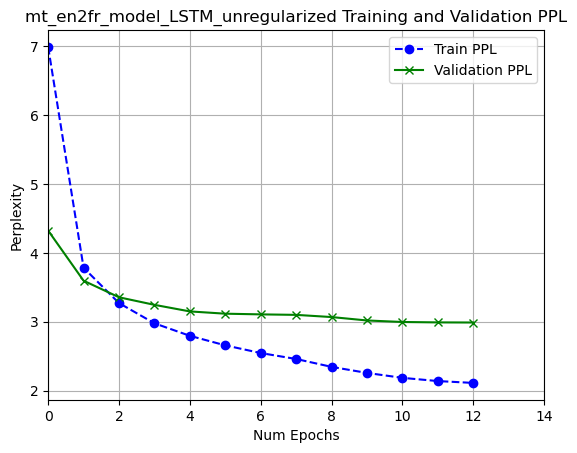

In [26]:
plot_train_valid(metrics_unregularized_DICT,save_plot=True,show_plot=True)

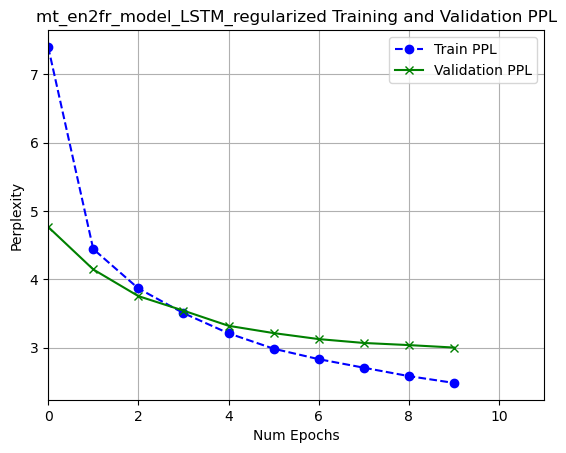

In [27]:
plot_train_valid(metrics_regularized_DICT,save_plot=True,show_plot=True)

# 3. Hyperparameter Tuning Using LSTMs

### 3.1 Variable Initializations

In [ ]:
base_path_ext = "data/"
current_application_ext = "machine_translation/"
data_type_ext = "output_data/"
model_type_ext = "lstm/"
experiment_type_ext = "hyperparameter_tune/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

# Set random seed
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

global device

device = setup_device()

In [ ]:
# Hyperparameters
set_of_hyperparams = {
    "model_name": "mt_en2fr_model_LSTM_tune",
    "save_interval_list": [10],
    "batch_size_list": [32],
    "seq_length_list": [32],
    "num_layers_list": [2], 
    "decay_list": [1.2],
    "layer_size_list": [128,256,512],
    "dropout_list": [0.0,0.25,0.5],
    "init_weight_list": [0.08],
    "lr_list": [0.5,0.25],
    "vocab_size_list": [10000],
    "max_epoch_list": [4],
    "max_max_epoch_list": [30],
    "max_grad_norm_list": [5],
    "beam_search": [True],
    "beam_width": [12,20]
}

### 3.2 Perform An Experiment

In [ ]:
def single_experiment(params,save_plot=True,show_plot=True,is_hyperparameter_tune=False,model_class="LSTMModel"):
    print("------------------------------------------------------------------------------")
    print(f"Running experiment with parameters: {params}")
    start_time = time.time()    
    data_train,data_valid,data_test,src_vocab_map,tgt_vocab_map = get_datasets(params)

    batched_data_train,batched_data_valid,batched_data_test = pad_and_batch_data(data_train,data_valid,data_test,src_vocab_map,tgt_vocab_map,params)

    epoch_num = 0 
    model,model_path,metrics_DICT = check_and_load_model(params,epoch_num,model_class=model_class)
    encoder = model['encoder']
    decoder = model['decoder']
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()),params["lr"])

    # Training loop
    patience = False # Set to 0, None, or False to disable early stopping
    model,metrics_DICT = train(batched_data_train,batched_data_valid,model,metrics_DICT,params,optimizer,criterion,tgt_vocab_map)

    model,model_path,metric_DICT = check_and_load_model(params,metrics_DICT["best_epoch"],best_model=True)
    test_ppl,test_bleu,metrics_DICT = evaluate(batched_data_test,model['encoder'],model['decoder'],metrics_DICT,params,criterion,tgt_vocab_map)    
    
    plot_train_valid(metrics_DICT,save_plot=save_plot,show_plot=show_plot,is_hyperparameter_tune=is_hyperparameter_tune)
    print(f"Experiment completed in {time.time() - start_time:.2f} seconds")
    print()
    return metrics_DICT, model_path

### 3.3 Perform All Experiments

In [ ]:
def perform_all_experiments(set_of_hyperparams,load_all_results=True,save_plot=True,show_plot=False,model_class="LSTMModel"):
    base_model_name = set_of_hyperparams["model_name"]
    all_results_path = f"{metrics_filepath_ext}{base_model_name}_all_results.pkl"

    all_results_DICT = load_PKL(all_results_path)

    # Initialize keys on first run
    is_initialized = len(all_results_DICT) > 0

    # Extract hyperparameter keys and values
    keys = [k for k in set_of_hyperparams if k.endswith("_list")]
    value_lists = [set_of_hyperparams[k] for k in keys]

    # Generate all hyperparameter combinations
    for values in itertools.product(*value_lists):
        current_params = {}
        for key, value in zip(keys, values):
            param_key = key.replace("_list", "")
            current_params[param_key] = value

        # Create model name
        model_name = base_model_name
        model_name += "_"
        for key in current_params:
            model_name += f"{key}{current_params[key]}"
            
        model_name = model_name.replace("save_interval","svint")
        model_name = model_name.replace("batch_size","bsiz")
        model_name = model_name.replace("seq_length","sqlen")
        model_name = model_name.replace("num_layers","nlyrs")
        model_name = model_name.replace("decay","dc")
        model_name = model_name.replace("layer_size","lyrsiz")
        model_name = model_name.replace("dropout","drop")
        model_name = model_name.replace("init_weight","iniwt")
        model_name = model_name.replace("lr","lr")
        model_name = model_name.replace("vocab_size","vcsiz")
        model_name = model_name.replace("max_max_epoch","mxmxepch")
        model_name = model_name.replace("max_epoch","mxepch")
        model_name = model_name.replace("max_grad_norm","mxgrdn")
        model_name = model_name.replace("beam_search","bmsch")
        model_name = model_name.replace("beam_width","bmwd")
                        
        current_params["model_name"] = model_name

        # Skip based on stored model names (optional)
        if is_initialized and "list_of_model_name" in all_results_DICT and model_name in all_results_DICT["list_of_model_name"]:
            print(f"Skipping previously completed: {model_name}")
            continue

        result_DICT,model_path = single_experiment(current_params,save_plot=save_plot,show_plot=show_plot,is_hyperparameter_tune=True,model_class=model_class)

        # Initialize structure if first successful run
        if not is_initialized:
            for key in result_DICT:
                new_key = "list_of_"+key
                all_results_DICT[new_key] = []
            is_initialized = True

        # Append each field
        for key, value in result_DICT.items():
            new_key = "list_of_"+key
            all_results_DICT[new_key].append(value)

        # Save after each run
        save_PKL(all_results_DICT,all_results_path)

    save_PKL(all_results_DICT, all_results_path)
    return all_results_DICT

In [ ]:
# all_results_DICT = perform_all_experiments(set_of_hyperparams,load_all_results=True,show_plot=False)

### 3.4 Find Best Experiment

In [ ]:
def get_best_model_by_valid_bleu(all_results_DICT,set_of_hyperparams):
    best_models_params_and_results_DICT = {
        "best_unregularized_model": {},
        "best_regularized_model": {}
    }
    
    best_index_unregularized = None
    best_valid_bleu_unregularized = -np.inf
    
    best_index_regularized = None
    best_valid_bleu_regularized = -np.inf

    base_model_name = set_of_hyperparams["model_name"]
    best_model_params_summary_path = f"{metrics_filepath_ext}{base_model_name}_best_hyperparameters_summary.pkl"

    # Loop through all experiments by index
    for i in range(len(all_results_DICT["list_of_model_name"])):
        valid_ppl = all_results_DICT["list_of_best_valid_ppl"][i]
        valid_bleu = all_results_DICT["list_of_best_valid_bleu"][i]
        dropout = all_results_DICT["list_of_dropout"][i]
        model_name = all_results_DICT["list_of_model_name"][i]
        
        is_regularized = dropout > 0.0
        model_type = "best_regularized_model" if is_regularized else "best_unregularized_model"

        print(f"[{model_type}] Model: {model_name} | Val PPL: {valid_ppl:.4f} | Val BLEU: {valid_bleu:.4f}")

        if not is_regularized and valid_bleu > best_valid_bleu_unregularized:
            best_index_unregularized = i
            best_valid_bleu_unregularized = valid_bleu
        elif is_regularized and valid_bleu > best_valid_bleu_regularized:
            best_index_regularized = i
            best_valid_bleu_regularized = valid_bleu

    for model_type in ["best_unregularized_model", "best_regularized_model"]:
        for key in all_results_DICT:
            if model_type == "best_unregularized_model":
                best_models_params_and_results_DICT[model_type][key.replace("list_of_","")] = all_results_DICT[key][best_index_unregularized]
            else:
                best_models_params_and_results_DICT[model_type][key.replace("list_of_","")] = all_results_DICT[key][best_index_regularized]
    
        curr_best_model_params_and_results_DICT = best_models_params_and_results_DICT[model_type]
        print("------------------------------------------------------------------------------")
        if curr_best_model_params_and_results_DICT:
            print(f"Best {model_type} model based on validation PPL:")
            for key in curr_best_model_params_and_results_DICT:
                if not key.endswith("_list"):
                    print(f"{key}: {curr_best_model_params_and_results_DICT[key]}")
        else:
            print(f"No {model_type} model found.")
        print()

    # Save summary to file
    save_PKL(best_models_params_and_results_DICT,best_model_params_summary_path)
    return best_models_params_and_results_DICT

In [ ]:
# best_models_params_and_results_DICT = get_best_model_by_valid_bleu(all_results_DICT,set_of_hyperparams)

### 3.5 Plot Best Experiment Metrics

In [ ]:
# plot_train_valid(best_models_params_and_results_DICT['best_unregularized_model'],save_plot=True,show_plot=True)

In [ ]:
# plot_train_valid(best_models_params_and_results_DICT['best_regularized_model'],save_plot=True,show_plot=True)

# 4. Original Experiment Using GRUs

### 4.1 Variable Initializations

In [105]:
base_path_ext = "data/"
current_application_ext = "machine_translation/"
data_type_ext = "output_data/"
model_type_ext = "gru/"
experiment_type_ext = "original/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

# Set random seed
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

global device

device = setup_device()

In [106]:
# Hyperparameters
params_unregularized = {
    "model_name": "mt_en2fr_model_GRU_unregularized",
    "src_lang": "en",
    "tgt_lang": "fr",
    "save_interval": 10,
    "batch_size": 256,
    "seq_length": 32,
    "num_layers": 2,
    "decay": 2,
    "layer_size": 256,
    "dropout": 0.0,
    "init_weight": 0.1,
    "lr": 0.01,
    "src_vocab_size": 10000,
    "tgt_vocab_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 13,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

In [107]:
params_regularized = {
    "model_name": "mt_en2fr_model_GRU_regularized",
    "src_lang": "en",
    "tgt_lang": "fr",
    "save_interval": 10,
    "batch_size": 256,
    "seq_length": 32,
    "num_layers": 2,
    "decay": 1.2,
    "layer_size": 256,
    "dropout": 0.25,
    "init_weight": 0.08,
    "lr": 0.01,
    "src_vocab_size": 10000,
    "tgt_vocab_size": 10000,
    "max_epoch": 6,
    "max_max_epoch": 39,
    "max_grad_norm": 5,
    "beam_search": True,
    "beam_width": 12
}

### 4.2 GRU Cell Class

In [108]:
class GRUCell(nn.Module):
    def __init__(self,input_size,hidden_size):
        super(GRUCell,self).__init__()
        self.hidden_size = hidden_size

        self.W_z = nn.Linear(input_size,hidden_size)
        self.U_z = nn.Linear(hidden_size,hidden_size)

        self.W_r = nn.Linear(input_size,hidden_size)
        self.U_r = nn.Linear(hidden_size,hidden_size)

        self.W_h = nn.Linear(input_size,hidden_size)
        self.U_h = nn.Linear(hidden_size,hidden_size)

    def forward(self,x,prev_h):
        z = torch.sigmoid(self.W_z(x) + self.U_z(prev_h))
        r = torch.sigmoid(self.W_r(x) + self.U_r(prev_h))
        h_tilde = torch.tanh(self.W_h(x) + r*self.U_h(prev_h))
        next_h = (1 - z)*h_tilde + z*prev_h
        return next_h

### 4.3 GRU Encoder Class

In [109]:
class GRUEncoder(nn.Module):
    def __init__(self, params):
        super(GRUEncoder, self).__init__()
        self.embedding = nn.Embedding(params["src_vocab_size"], params["layer_size"])
        self.gru_cells = nn.ModuleList([
            GRUCell(params["layer_size"], params["layer_size"]) for _ in range(params["num_layers"])
        ])
        self.dropout = nn.Dropout(params["dropout"])
        self.init_weights(params)

    def init_weights(self, params):
        for param in self.parameters():
            param.data.uniform_(-params["init_weight"], params["init_weight"])

        for name, param in self.named_parameters():
            if 'bias' in name:
                nn.init.zeros_(param)
                if 'reset' in name or 'update' in name:  # Reset and update gates
                    n = param.size(0)
                    param.data.fill_(0)  # Set biases for reset and update gates to 0
                if 'candidate' in name:  # Candidate state
                    n = param.size(0)
                    param.data.fill_(0)

    def forward(self, x, hidden_states):
        x = self.embedding(x)  # [batch_size, seq_len] → [batch_size, seq_len, emb_dim]
        if x.dim() == 2:
            x = x.unsqueeze(1)
        batch_size, seq_len, _ = x.size()
        outputs = []

        for t in range(seq_len):
            x_t = x[:, t, :]  # [batch_size, emb_dim]
            for i, cell in enumerate(self.gru_cells):
                h_prev = hidden_states[i]
                h_next = cell(x_t, h_prev)
                x_t = self.dropout(h_next)
                hidden_states[i] = h_next
            outputs.append(x_t.unsqueeze(1))  # [batch_size, 1, hidden]

        outputs = torch.cat(outputs, dim=1)  # [batch_size, seq_len, hidden]
        return outputs, hidden_states

    def init_hidden(self, params, device, num_batches=None):
        if not num_batches:
            num_batches = params["batch_size"]
        return [torch.zeros(num_batches, params["layer_size"], device=device) for _ in range(params["num_layers"])]

### 4.4 GRU Decoder Class

In [110]:
class GRUDecoder(nn.Module):
    def __init__(self, params):
        super(GRUDecoder, self).__init__()
        self.embedding = nn.Embedding(params["tgt_vocab_size"], params["layer_size"])
        self.gru_cells = nn.ModuleList([
            GRUCell(params["layer_size"], params["layer_size"]) for _ in range(params["num_layers"])
        ])
        self.dropout = nn.Dropout(params["dropout"])
        self.fc = nn.Linear(params["layer_size"], params["tgt_vocab_size"])
        self.init_weights(params)

    def init_weights(self, params):
        for param in self.parameters():
            param.data.uniform_(-params["init_weight"], params["init_weight"])

        for name, param in self.named_parameters():
            if 'bias' in name:
                nn.init.zeros_(param)  # Initialize biases to 0
                if 'reset' in name or 'update' in name:  # Reset and Update gates
                    param.data.fill_(0)  # Reset and Update gate biases to 0
                if 'candidate' in name:  # Candidate gate
                    param.data.fill_(0)

    def forward(self, x, hidden_states):
        x = self.embedding(x)  # [batch_size, emb_dim]
        for i, cell in enumerate(self.gru_cells):
            h_prev = hidden_states[i]
            h_next = cell(x, h_prev)
            x = self.dropout(h_next)
            hidden_states[i] = h_next
        output = self.fc(x)  # [batch_size, vocab_size]
        return output, hidden_states


### 4.5 Model Initialization

In [111]:


# Initialize model
last_epoch_unregularized = False #Change this to False to train from scratch
epoch_num_unregularized = 0 #Change this to load at a specific epoch
criterion = torch.nn.CrossEntropyLoss() 

model_unregularized,model_path_unregularized,metrics_unregularized_DICT = check_and_load_model(params_unregularized,epoch_num_unregularized,last_epoch=last_epoch_unregularized,model_class="GRUModel")
encoder_unregularized = model_unregularized['encoder']
decoder_unregularized = model_unregularized['decoder']
optimizer_unregularized = optim.Adam(list(encoder_unregularized.parameters()) + list(decoder_unregularized.parameters()), lr=params_unregularized["lr"])

In [112]:
# Initialize model
last_epoch_regularized = False #Change this to False to train from scratch
epoch_num_regularized = 0 #Change this to load at a specific epoch

model_regularized,model_path_regularized,metrics_regularized_DICT = check_and_load_model(params_regularized,epoch_num_regularized,last_epoch=last_epoch_regularized,model_class="GRUModel")
encoder_regularized = model_regularized['encoder']
decoder_regularized = model_regularized['decoder']
optimizer_regularized = optim.Adam(list(encoder_regularized.parameters()) + list(decoder_regularized.parameters()), lr=params_regularized["lr"])

### 4.6. Train and Evaluate Model

In [113]:
num_batches = len(batched_data_train_unregularized)
batches_to_use = num_batches//10
patience_unregularized = False # Set to 0, None, or False to disable early stopping

batched_data_train_unregularized = batched_data_train_unregularized[:batches_to_use]
batched_data_valid_unregularized = batched_data_valid_unregularized[:batches_to_use]
batched_data_test_unregularized = batched_data_test_unregularized[:batches_to_use]

# Training loop
patience_unregularized = True # Set to 0, None, or False to disable early stopping
model_unregularized,metrics_DICT = train(batched_data_train_unregularized,batched_data_valid_unregularized,model_unregularized,metrics_unregularized_DICT,params_unregularized,optimizer_unregularized,criterion,tgt_vocab_map_unregularized)

model_unregularized,_,metrics_unregularized_DICT = check_and_load_model(params_unregularized,metrics_DICT["best_epoch"],best_model=True, model_class="GRUModel")
test_ppl,test_bleu,metrics_unregularized_DICT = evaluate(batched_data_test_unregularized,model_unregularized['encoder'],model_unregularized['decoder'],metrics_unregularized_DICT,params_unregularized,criterion,tgt_vocab_map_unregularized)

Training Epochs:   8%|▊         | 1/13 [01:50<22:09, 110.78s/it]

Epoch 1/13, Train PPL: 6.1082, Val PPL: 4.1908


Training Epochs:  15%|█▌        | 2/13 [03:43<20:28, 111.64s/it]

Epoch 2/13, Train PPL: 3.7263, Val PPL: 3.6725


Training Epochs:  23%|██▎       | 3/13 [05:34<18:37, 111.76s/it]

...

Training Epochs:  54%|█████▍    | 7/13 [12:54<10:59, 109.96s/it]

Epoch 7/13, Train PPL: 2.0985, Val PPL: 3.0482


Training Epochs:  54%|█████▍    | 7/13 [14:44<12:37, 126.33s/it]

Epoch 8/13, Train PPL: 1.9739, Val PPL: 3.0958
Early stopping at epoch 8 (no improvement for 3 epochs).


Test PPL: 3.0267


In [115]:
num_batches = len(batched_data_train_regularized)
batches_to_use = num_batches//10
patience_regularized = False # Set to 0, None, or False to disable early stopping

batched_data_train_regularized = batched_data_train_regularized[:batches_to_use]
batched_data_valid_regularized = batched_data_valid_regularized[:batches_to_use]
batched_data_test_regularized = batched_data_test_regularized[:batches_to_use]

# Training loop
patience_regularized = True # Set to 0, None, or False to disable early stopping
model_regularized,metrics_DICT = train(batched_data_train_regularized,batched_data_valid_regularized,model_regularized,metrics_regularized_DICT,params_regularized,optimizer_regularized,criterion,tgt_vocab_map_regularized)

model_regularized,_,metrics_regularized_DICT = check_and_load_model(params_regularized,metrics_DICT["best_epoch"],best_model=True, model_class="GRUModel")
test_ppl,test_bleu,metrics_regularized_DICT = evaluate(batched_data_test_regularized,model_regularized['encoder'],model_regularized['decoder'],metrics_regularized_DICT,params_regularized,criterion,tgt_vocab_map_regularized)

Training Epochs:   0%|          | 0/19 [00:11<?, ?it/s]

Epoch 21/39, Train PPL: 1.5034, Val PPL: 2.8050
Early stopping at epoch 21 (no improvement for 3 epochs).


Test PPL: 2.6988


### 4.7. Plotting Results

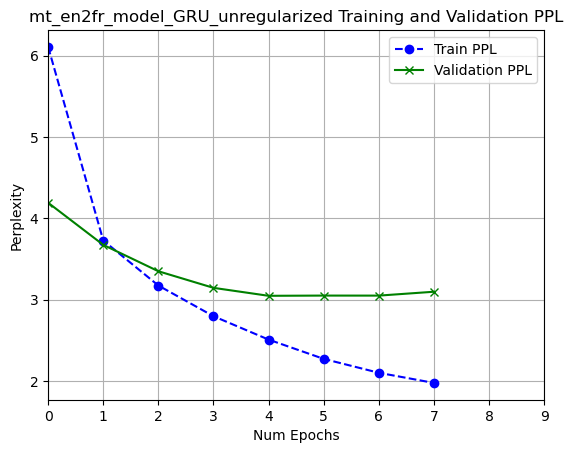

In [116]:
plot_train_valid(metrics_unregularized_DICT,save_plot=True,show_plot=True)

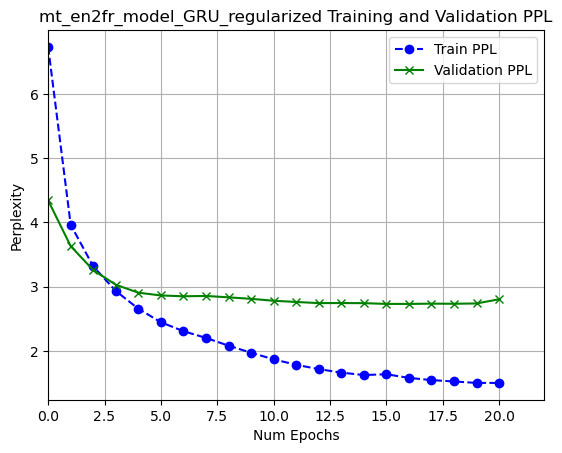

In [117]:
plot_train_valid(metrics_regularized_DICT,save_plot=True,show_plot=True)

# 5. Hyperparameter Tuning Using GRUs

### 5.1 Variable Initializations

In [ ]:
base_path_ext = "data/"
current_application_ext = "machine_translation/"
data_type_ext = "output_data/"
model_type_ext = "gru/"
experiment_type_ext = "hyperparameter_tune/"
metrics_OR_models_OR_plots_ext_list = ["metrics/","models/","plots/"]
filepath_ext = base_path_ext + current_application_ext + data_type_ext + model_type_ext + experiment_type_ext

global metrics_filepath_ext
global models_filepath_ext
global plots_filepath_ext

metrics_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[0]
models_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[1] 
plots_filepath_ext = filepath_ext + metrics_OR_models_OR_plots_ext_list[2]

# Set random seed
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

global device

device = setup_device()

In [ ]:
# Hyperparameters
set_of_hyperparams = {
    "model_name": "mt_en2fr_model_GRU_tune",
    "save_interval_list": [10],
    "batch_size_list": [32],
    "seq_length_list": [32],
    "num_layers_list": [2], 
    "decay_list": [1.2],
    "layer_size_list": [128,256,512],
    "dropout_list": [0.0,0.25,0.5],
    "init_weight_list": [0.08],
    "lr_list": [0.5,0.25],
    "vocab_size_list": [10000],
    "max_epoch_list": [4],
    "max_max_epoch_list": [30],
    "max_grad_norm_list": [5],
    "beam_search": [True],
    "beam_width": [12,20]
}

### 5.2 Perform All Experiments

In [ ]:
# all_results_DICT = perform_all_experiments(set_of_hyperparams,load_all_results=True,show_plot=False,model_class="GRUModel")

### 5.3 Find Best Experiment

In [ ]:
# best_models_params_and_results_DICT = get_best_model_by_valid_bleu(all_results_DICT,set_of_hyperparams)

### 5.4 Plot Best Experiment Metrics

In [ ]:
# plot_train_valid(best_models_params_and_results_DICT['best_unregularized_model'],save_plot=True,show_plot=True)

In [ ]:
# plot_train_valid(best_models_params_and_results_DICT['best_regularized_model'],save_plot=True,show_plot=True)